In [18]:
from langgraph.graph import StateGraph, START, MessagesState
from langgraph.checkpoint.memory import InMemorySaver
from dotenv import load_dotenv

from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace
from langchain_core.messages.utils import trim_messages,count_tokens_approximately

In [19]:
load_dotenv()

True

In [20]:
llm1 = HuggingFaceEndpoint(repo_id="Qwen/Qwen2.5-7B-Instruct")
model = ChatHuggingFace(llm=llm1)

In [21]:
MAX_TOKENS = 1000

In [22]:
def call_model(state: MessagesState):
    
    # Trim conversation history -> last N messages that fit within the token budget
    messages = trim_messages(
        state["messages"],
        strategy="last",                      
        token_counter=count_tokens_approximately,
        max_tokens=MAX_TOKENS
    )

    print('Current Token Count ->', count_tokens_approximately(messages=messages))

    for message in messages:
        print(message.content)

    response = model.invoke(messages)

    return {"messages": [response]}

In [23]:
builder = StateGraph(MessagesState)
builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

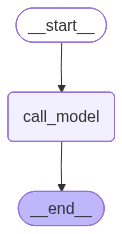

In [24]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)
graph

In [25]:
config = {"configurable": {"thread_id": "chat-1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Hi, my name is Shubham."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 10
Hi, my name is Shubham.


'Hello Shubham! Nice to meet you. How can I assist you today? Whether you have questions, need information, or just want to chat, feel free to let me know.'

In [26]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "I am learning LangGraph."}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 64
Hi, my name is Shubham.
Hello Shubham! Nice to meet you. How can I assist you today? Whether you have questions, need information, or just want to chat, feel free to let me know.
I am learning LangGraph.


"That sounds interesting! LangGraph is likely a tool or framework related to natural language processing (NLP) or graph databases. Could you provide a bit more context about what you're learning? For example:\n\n1. Are you working with a specific library or framework like LangGraph?\n2. What are your goals in learning it?\n3. Are you facing any specific challenges or questions while learning?\n\nI can help you with tutorials, examples, or any other information you might need!"

In [27]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "Can you explain short term memory?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 201
Hi, my name is Shubham.
Hello Shubham! Nice to meet you. How can I assist you today? Whether you have questions, need information, or just want to chat, feel free to let me know.
I am learning LangGraph.
That sounds interesting! LangGraph is likely a tool or framework related to natural language processing (NLP) or graph databases. Could you provide a bit more context about what you're learning? For example:

1. Are you working with a specific library or framework like LangGraph?
2. What are your goals in learning it?
3. Are you facing any specific challenges or questions while learning?

I can help you with tutorials, examples, or any other information you might need!
Can you explain short term memory?


'Certainly! Short-term memory (STM) is a component of human memory that holds a small amount of information for a short period of time. It plays a crucial role in processing and preparing information for long-term memory storage or for immediate use.\n\n### Key Characteristics of Short-Term Memory:\n\n1. **Limited Capacity**: Typically, short-term memory can hold about 7±2 items (also known as the magical number 7 theory by George Miller). This capacity can vary slightly depending on the individual.\n\n2. **Duration**: Information in short-term memory is retained for a very brief period, usually from a few seconds to a minute. It can be extended with rehearsal (repeatedly thinking about the information) or encoding it into long-term memory.\n\n3. **Processing**: Short-term memory is involved in the manipulation and processing of information. This includes tasks such as reading a sentence and interpreting its meaning, or solving a math problem.\n\n4. **Components**: Typically, short-ter

In [28]:
result = graph.invoke(
    {"messages": [{"role": "user", "content": "What is my name?"}]},
    config,
)

result["messages"][-1].content

Current Token Count -> 872
Hi, my name is Shubham.
Hello Shubham! Nice to meet you. How can I assist you today? Whether you have questions, need information, or just want to chat, feel free to let me know.
I am learning LangGraph.
That sounds interesting! LangGraph is likely a tool or framework related to natural language processing (NLP) or graph databases. Could you provide a bit more context about what you're learning? For example:

1. Are you working with a specific library or framework like LangGraph?
2. What are your goals in learning it?
3. Are you facing any specific challenges or questions while learning?

I can help you with tutorials, examples, or any other information you might need!
Can you explain short term memory?
Certainly! Short-term memory (STM) is a component of human memory that holds a small amount of information for a short period of time. It plays a crucial role in processing and preparing information for long-term memory storage or for immediate use.

### Key C

'Your name is Shubham!'

In [29]:
for item in graph.get_state({"configurable": {"thread_id": "chat-1"}}).values['messages']:
    print(item.content)
    print('-'*120)

Hi, my name is Shubham.
------------------------------------------------------------------------------------------------------------------------
Hello Shubham! Nice to meet you. How can I assist you today? Whether you have questions, need information, or just want to chat, feel free to let me know.
------------------------------------------------------------------------------------------------------------------------
I am learning LangGraph.
------------------------------------------------------------------------------------------------------------------------
That sounds interesting! LangGraph is likely a tool or framework related to natural language processing (NLP) or graph databases. Could you provide a bit more context about what you're learning? For example:

1. Are you working with a specific library or framework like LangGraph?
2. What are your goals in learning it?
3. Are you facing any specific challenges or questions while learning?

I can help you with tutorials, examples, 